# Benchmarking Time-Series Foundation Models for Equity Return Forecasting

This report summarizes the FINM-33200 final project: a WRDS-backed benchmark of next-day US equity excess-return forecasts. The benchmark uses `src/` for WRDS pulls and feature construction, then `bench/` for walk-forward evaluation, model wrappers, metrics, latency, and plots.

## Project Question

Do zero-shot and covariate-aware time-series foundation models improve next-day US equity excess-return forecasts relative to simple linear and tree baselines? We evaluate this with out-of-sample daily forecasts, pooled accuracy metrics, and a long-short decile portfolio formed from model forecasts.

## Data and Forecast Timing

The canonical benchmark is WRDS-backed. Forecasts are made after market close on the `asof` date and scored against the next trading day's excess return, `excess_ret[t+1]`. Lagged features and same-day close information are allowed only when they would be known at that timestamp.

## Runtime Environment

The report stage records a cleaned hardware and software summary so GPU-dependent runtime and latency results are interpretable.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'bench').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from bench.report_notebook import (
    display_benchmark,
    display_cross_benchmark_summary,
    display_runtime_environment,
)

display_runtime_environment()

,component,value
0,Run timestamp,2026-05-26T01:18:09+00:00
1,OS,Windows 11 (AMD64)
2,Python,CPython 3.12.10 via python.exe
3,CPU,"Intel(R) Core(TM) i7-14700K (20 physical, 28 l..."
4,RAM,63.8 GB
5,GPU 0,RTX 5080 (Blackwell; compute 12.0; 15.9 GB VRA...
6,PyTorch/CUDA,"torch 2.9.1+cu130, CUDA 13.0, available=True"
7,CUDA kernels,"sm_75, sm_80, sm_86, sm_90, sm_100, sm_120"


#### Key Package Versions

,package,version
0,catboost,1.2.7
1,chronos-forecasting,2.2.2
2,jax,0.6.1
3,jaxlib,0.6.1
4,lightgbm,4.6.0
5,numpy,1.26.4
6,pandas,2.2.3
7,scikit-learn,1.8.0
8,timesfm,2.0.0
9,torch,2.9.1+cu130


## Model Families

Each default benchmark config includes simple baselines, supervised baselines, Chronos-Bolt, Chronos-2, TimesFM 2.5 target-only, and TimesFM 2.5 XReg where covariates are available. The MOIRAI wrapper is implemented but treated as optional because the Uni2TS dependency stack conflicts with the Torch/CUDA build needed for the RTX 50-series run environment.

## Evaluation Protocol

Reported metrics are pooled out-of-sample R2 against a zero-return forecast, MAE, RMSE, directional accuracy, macro F1, and annualized long-short decile portfolio statistics. The WRDS intraday benchmark also records latency for every configured model, including TimesFM.

## Cross-Benchmark Summary

In [2]:
display_cross_benchmark_summary()

,benchmark,model,family,r2_oos,mae,rmse,dir_acc,f1,sharpe,ann_return,max_dd,n_obs,n_dates
0,B1: WRDS Daily 2022,zero,Simple baseline,0.0000,0.0166,0.0232,0.5100,0.3377,NaN,NaN,NaN,25100,251
1,B1: WRDS Daily 2022,mean,Simple baseline,-0.0047,0.0167,0.0233,0.4896,0.3368,-1.2431,-0.4861,-0.4542,25100,251
2,B1: WRDS Daily 2022,ridge,Supervised baseline,-0.0198,0.0169,0.0235,0.4993,0.4839,0.7255,0.2127,-0.2238,25100,251
3,B1: WRDS Daily 2022,lightgbm,Supervised baseline,-0.0400,0.0168,0.0237,0.5157,0.5059,0.6673,0.1754,-0.2425,25100,251
4,B1: WRDS Daily 2022,catboost,Supervised baseline,-0.0501,0.0169,0.0238,0.5102,0.4999,0.1921,0.0568,-0.2353,25100,251
5,B1: WRDS Daily 2022,chronos-bolt-252,Chronos-Bolt,-0.0103,0.0167,0.0234,0.5027,0.5019,0.9748,0.3045,-0.1884,25100,251
6,B1: WRDS Daily 2022,chronos-2-252,Chronos-2,-0.0315,0.0169,0.0236,0.4844,0.4796,-0.7901,-0.1891,-0.2862,25100,251
7,B1: WRDS Daily 2022,timesfm-2.5-252,TimesFM,-0.0219,0.0167,0.0235,0.5024,0.5021,-0.1333,-0.0375,-0.2406,25100,251
8,B1: WRDS Daily 2022,timesfm-2.5-xreg-252,TimesFM XReg,-1.2937,0.0243,0.0352,0.5132,0.5131,0.2252,0.0704,-0.2777,25100,251
9,B2: WRDS Daily 2023,zero,Simple baseline,0.0000,0.0114,0.0165,0.4812,0.3249,NaN,NaN,NaN,24750,250


## Benchmark 1: WRDS Daily 2022

Daily CRSP/Compustat/Fama-French panel, top 100 stocks by market capitalization, trained through 2021 and evaluated in 2022.

,field,value
0,config,configs/wrds_daily_2022_full.yaml
1,results,results/wrds_daily_2022_full
2,data source,wrds_panel
3,sample,2015-01-01 to 2022-12-31; OOS 2022
4,horizon,1
5,latency enabled,False


#### Configured Model Coverage

,family,configured models,present in current artifacts
0,Chronos-Bolt,chronos-bolt-252,chronos-bolt-252
1,Chronos-2,chronos-2-252,chronos-2-252
2,TimesFM,timesfm-2.5-252,timesfm-2.5-252
3,TimesFM XReg,timesfm-2.5-xreg-252,timesfm-2.5-xreg-252


#### Accuracy and Portfolio Metrics

,model,family,r2_oos,mae,rmse,dir_acc,f1,sharpe,ann_return,max_dd,n_obs,n_dates
0,zero,Simple baseline,0.0000,0.0166,0.0232,0.5100,0.3377,NaN,NaN,NaN,25100,251
1,mean,Simple baseline,-0.0047,0.0167,0.0233,0.4896,0.3368,-1.2431,-0.4861,-0.4542,25100,251
2,ridge,Supervised baseline,-0.0198,0.0169,0.0235,0.4993,0.4839,0.7255,0.2127,-0.2238,25100,251
3,lightgbm,Supervised baseline,-0.0400,0.0168,0.0237,0.5157,0.5059,0.6673,0.1754,-0.2425,25100,251
4,catboost,Supervised baseline,-0.0501,0.0169,0.0238,0.5102,0.4999,0.1921,0.0568,-0.2353,25100,251
5,chronos-bolt-252,Chronos-Bolt,-0.0103,0.0167,0.0234,0.5027,0.5019,0.9748,0.3045,-0.1884,25100,251
6,chronos-2-252,Chronos-2,-0.0315,0.0169,0.0236,0.4844,0.4796,-0.7901,-0.1891,-0.2862,25100,251
7,timesfm-2.5-252,TimesFM,-0.0219,0.0167,0.0235,0.5024,0.5021,-0.1333,-0.0375,-0.2406,25100,251
8,timesfm-2.5-xreg-252,TimesFM XReg,-1.2937,0.0243,0.0352,0.5132,0.5131,0.2252,0.0704,-0.2777,25100,251


#### Plots

**sharpe_by_model.png**

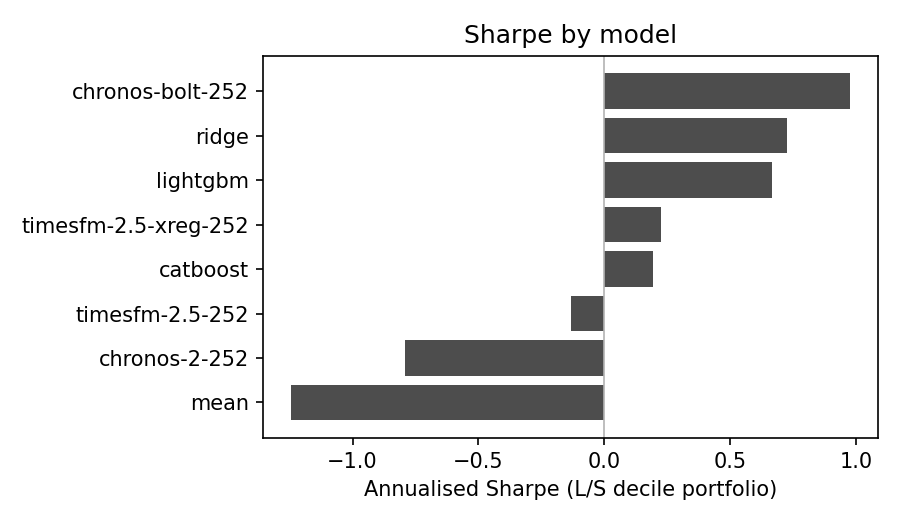

**equity_curves.png**

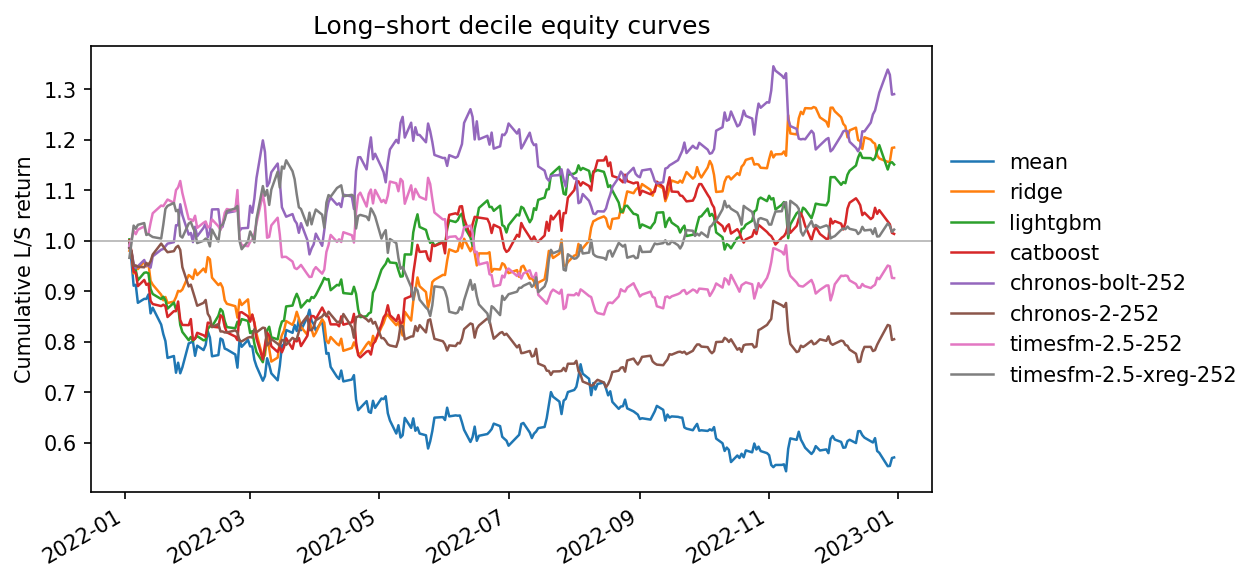

In [3]:
display_benchmark("wrds_daily_2022")

## Benchmark 2: WRDS Daily 2023

Same WRDS daily design, trained through 2022 and evaluated in 2023.

,field,value
0,config,configs/wrds_daily_2023_full.yaml
1,results,results/wrds_daily_2023_full
2,data source,wrds_panel
3,sample,2015-01-01 to 2023-12-31; OOS 2023
4,horizon,1
5,latency enabled,False


#### Configured Model Coverage

,family,configured models,present in current artifacts
0,Chronos-Bolt,chronos-bolt-252,chronos-bolt-252
1,Chronos-2,chronos-2-252,chronos-2-252
2,TimesFM,timesfm-2.5-252,timesfm-2.5-252
3,TimesFM XReg,timesfm-2.5-xreg-252,timesfm-2.5-xreg-252


#### Accuracy and Portfolio Metrics

,model,family,r2_oos,mae,rmse,dir_acc,f1,sharpe,ann_return,max_dd,n_obs,n_dates
0,zero,Simple baseline,0.0000,0.0114,0.0165,0.4812,0.3249,NaN,NaN,NaN,24750,250
1,mean,Simple baseline,0.0016,0.0114,0.0165,0.5177,0.3494,1.9631,0.4234,-0.1242,24750,250
2,ridge,Supervised baseline,-0.0195,0.0115,0.0167,0.4902,0.4820,-0.7961,-0.1480,-0.2845,24750,250
3,lightgbm,Supervised baseline,-0.0933,0.0121,0.0173,0.4821,0.4817,-1.0385,-0.1925,-0.2869,24750,250
4,catboost,Supervised baseline,-0.1220,0.0122,0.0175,0.4906,0.4902,-0.3552,-0.0641,-0.1652,24750,250
5,chronos-bolt-252,Chronos-Bolt,-0.0123,0.0115,0.0166,0.4987,0.4980,-0.2451,-0.0453,-0.1835,24750,250
6,chronos-2-252,Chronos-2,-0.0250,0.0115,0.0167,0.4978,0.4841,-0.5943,-0.1083,-0.1656,24750,250
7,timesfm-2.5-252,TimesFM,-0.0242,0.0115,0.0167,0.5038,0.4994,-0.6086,-0.1072,-0.1874,24750,250
8,timesfm-2.5-xreg-252,TimesFM XReg,-1.2145,0.0169,0.0246,0.5095,0.5088,0.7590,0.1441,-0.1198,24750,250


#### Plots

**sharpe_by_model.png**

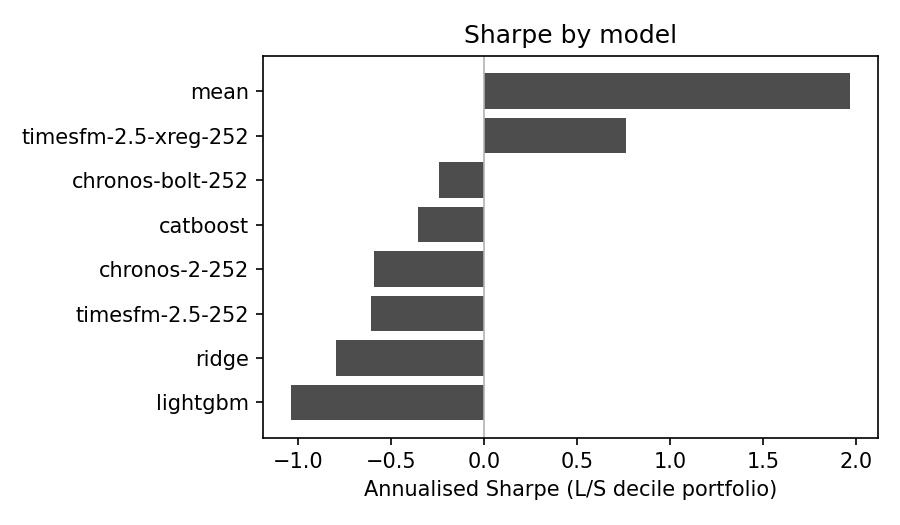

**equity_curves.png**

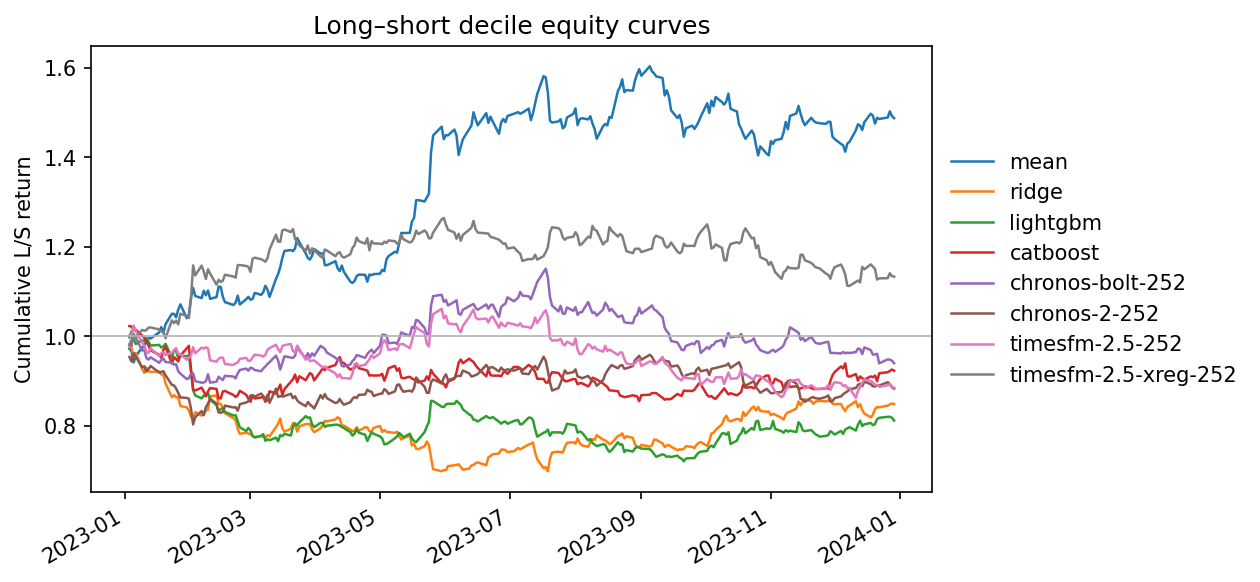

In [4]:
display_benchmark("wrds_daily_2023")

## Benchmark 3: Fama-French 25 Daily 2023

Public daily Fama-French 25 size/book-to-market portfolios, used as an external sanity benchmark that does not require WRDS credentials.

,field,value
0,config,configs/ff25_2023.yaml
1,results,results/ff25_2023
2,data source,ff25
3,sample,2000-01-01 to 2023-12-31; OOS 2023
4,horizon,1
5,latency enabled,False


#### Configured Model Coverage

,family,configured models,present in current artifacts
0,Chronos-Bolt,"chronos-bolt-21, chronos-bolt-252","chronos-bolt-21, chronos-bolt-252"
1,Chronos-2,"chronos-2-21, chronos-2-252","chronos-2-21, chronos-2-252"
2,TimesFM,"timesfm-2.5-21, timesfm-2.5-252","timesfm-2.5-21, timesfm-2.5-252"
3,TimesFM XReg,"timesfm-2.5-xreg-21, timesfm-2.5-xreg-252","timesfm-2.5-xreg-21, timesfm-2.5-xreg-252"


#### Accuracy and Portfolio Metrics

,model,family,r2_oos,mae,rmse,dir_acc,f1,sharpe,ann_return,max_dd,n_obs,n_dates
0,zero,Simple baseline,0.0000,0.0099,0.0127,0.4797,0.3242,NaN,NaN,NaN,6250,250
1,mean,Simple baseline,0.0025,0.0099,0.0127,0.5203,0.3422,0.5361,0.0640,-0.1417,6250,250
2,ridge,Supervised baseline,0.0036,0.0099,0.0127,0.5008,0.4251,-0.7582,-0.1166,-0.2460,6250,250
3,lightgbm,Supervised baseline,-0.0006,0.0099,0.0127,0.5195,0.4039,1.0656,0.1234,-0.0845,6250,250
4,catboost,Supervised baseline,0.0017,0.0099,0.0127,0.5104,0.4776,1.3533,0.1682,-0.1073,6250,250
5,chronos-bolt-21,Chronos-Bolt,-0.1489,0.0106,0.0136,0.4904,0.4900,-0.1227,-0.0167,-0.1471,6250,250
6,chronos-bolt-252,Chronos-Bolt,-0.0191,0.0100,0.0128,0.4837,0.4836,-0.1588,-0.0221,-0.1296,6250,250
7,chronos-2-21,Chronos-2,-0.1697,0.0107,0.0138,0.4890,0.4882,1.3557,0.1801,-0.0736,6250,250
8,chronos-2-252,Chronos-2,-0.0225,0.0101,0.0129,0.4531,0.4448,-0.3227,-0.0418,-0.1159,6250,250
9,timesfm-2.5-21,TimesFM,-0.1437,0.0106,0.0136,0.4917,0.4890,0.4571,0.0617,-0.1683,6250,250


#### Plots

**sharpe_by_model.png**

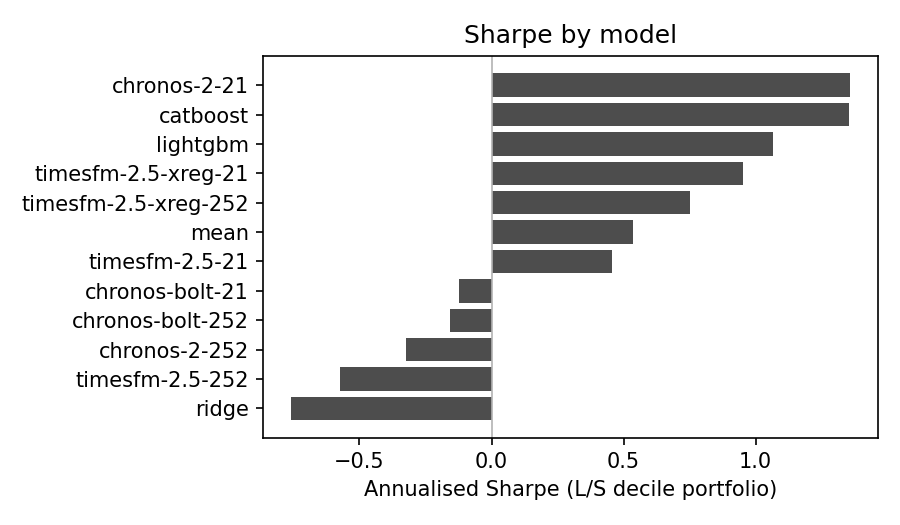

**equity_curves.png**

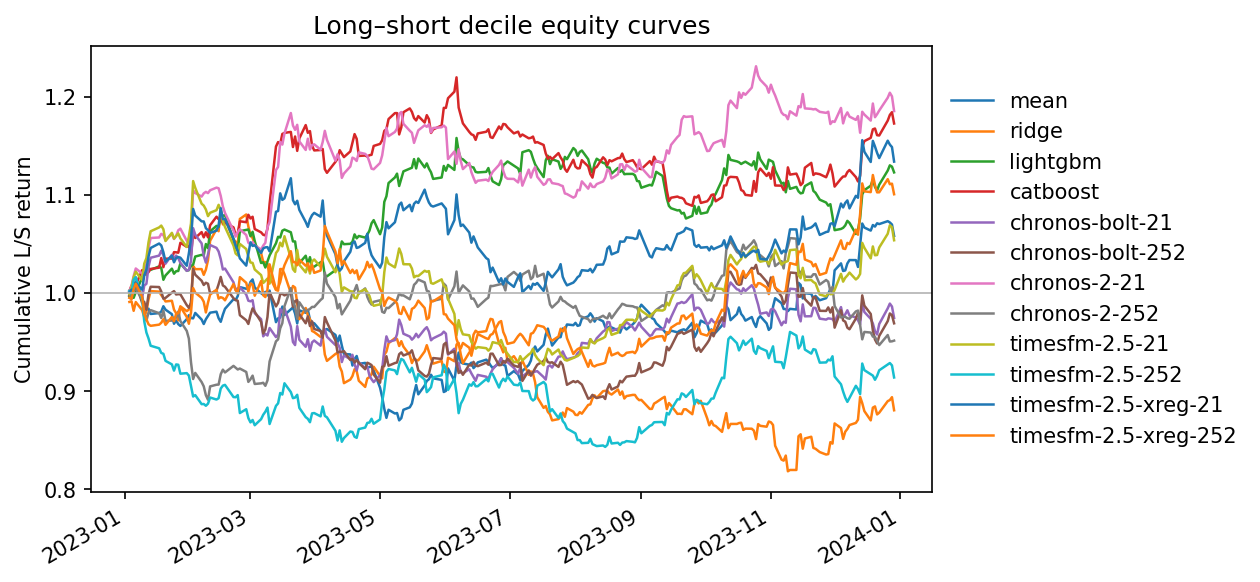

In [5]:
display_benchmark("ff25_2023")

## Benchmark 4: WRDS TAQ Intraday 1m

WRDS TAQ one-minute bars for ten large-cap stocks. This run is the short-horizon extension and records latency for every configured model.

,field,value
0,config,configs/intraday_1m_wrds.yaml
1,results,results/intraday_1m_wrds
2,data source,wrds
3,sample,2025-01-27 to 2025-01-31; OOS 2025-01-31 09:30...
4,horizon,1
5,latency enabled,True


#### Configured Model Coverage

,family,configured models,present in current artifacts
0,Chronos-Bolt,"chronos-bolt-60, chronos-bolt-252","chronos-bolt-60, chronos-bolt-252"
1,Chronos-2,"chronos-2-60, chronos-2-252","chronos-2-60, chronos-2-252"
2,TimesFM,"timesfm-2.5-60, timesfm-2.5-252","timesfm-2.5-60, timesfm-2.5-252"
3,TimesFM XReg,"timesfm-2.5-xreg-60, timesfm-2.5-xreg-252","timesfm-2.5-xreg-60, timesfm-2.5-xreg-252"


#### Accuracy and Portfolio Metrics

,model,family,r2_oos,mae,rmse,dir_acc,f1,sharpe,ann_return,max_dd,n_obs,n_dates
0,zero,Simple baseline,0.0000,0.0026,0.0131,0.5207,0.3424,NaN,NaN,NaN,3910,391
1,mean,Simple baseline,-0.0000,0.0026,0.0131,0.4788,0.4347,12.0194,6.2863,-0.0349,3910,391
2,ridge,Supervised baseline,0.0058,0.0026,0.0131,0.4977,0.4922,24.3405,250.7943,-0.2792,3910,391
3,lightgbm,Supervised baseline,-0.0848,0.0032,0.0136,0.5159,0.5120,-21.8416,-279.8585,-0.8155,3910,391
4,chronos-bolt-60,Chronos-Bolt,-0.0749,0.0027,0.0136,0.5054,0.5041,-34.9221,-410.3545,-0.8553,3910,391
5,chronos-bolt-252,Chronos-Bolt,-0.0115,0.0026,0.0132,0.5230,0.5156,-28.7921,-328.7557,-0.8268,3910,391
6,chronos-2-60,Chronos-2,0.0182,0.0027,0.0130,0.5120,0.5089,67.3660,632.2329,-0.1856,3910,391
7,chronos-2-252,Chronos-2,0.0162,0.0026,0.0130,0.5233,0.5177,77.1569,763.2204,-0.2430,3910,391
8,timesfm-2.5-60,TimesFM,-0.0118,0.0027,0.0132,0.5138,0.5089,11.7734,134.5463,-0.6920,3910,391
9,timesfm-2.5-252,TimesFM,0.0533,0.0026,0.0127,0.5243,0.5173,99.3435,1105.1199,-0.2139,3910,391


#### Latency

,model,family,fit_seconds,predict_mean,p50,p95,p99,assets_per_sec,bars_per_sec,n_calls
0,zero,Simple baseline,0.0477,0.0000,0.0000,0.0000,0.0001,280220.4499,28022.0450,391
1,mean,Simple baseline,0.0004,0.0001,0.0001,0.0001,0.0001,179007.9930,17900.7993,391
2,ridge,Supervised baseline,0.0104,0.0004,0.0003,0.0006,0.0007,26399.9039,2639.9904,391
3,lightgbm,Supervised baseline,2.9408,0.0011,0.0011,0.0012,0.0013,9285.5538,928.5554,391
4,chronos-bolt-60,Chronos-Bolt,0.0000,0.0532,0.0461,0.0482,0.0493,188.1159,18.8116,391
5,chronos-bolt-252,Chronos-Bolt,0.0000,0.0762,0.0756,0.0783,0.0794,131.1795,13.1179,391
6,chronos-2-60,Chronos-2,0.0000,0.1598,0.1588,0.1632,0.1682,62.5873,6.2587,391
7,chronos-2-252,Chronos-2,0.0000,0.3791,0.3775,0.3887,0.4100,26.3765,2.6377,391
8,timesfm-2.5-60,TimesFM,0.0000,0.0768,0.0686,0.0854,0.1043,130.2591,13.0259,391
9,timesfm-2.5-252,TimesFM,0.0000,0.0864,0.0820,0.1031,0.1147,115.7706,11.5771,391


#### Plots

**sharpe_by_model.png**

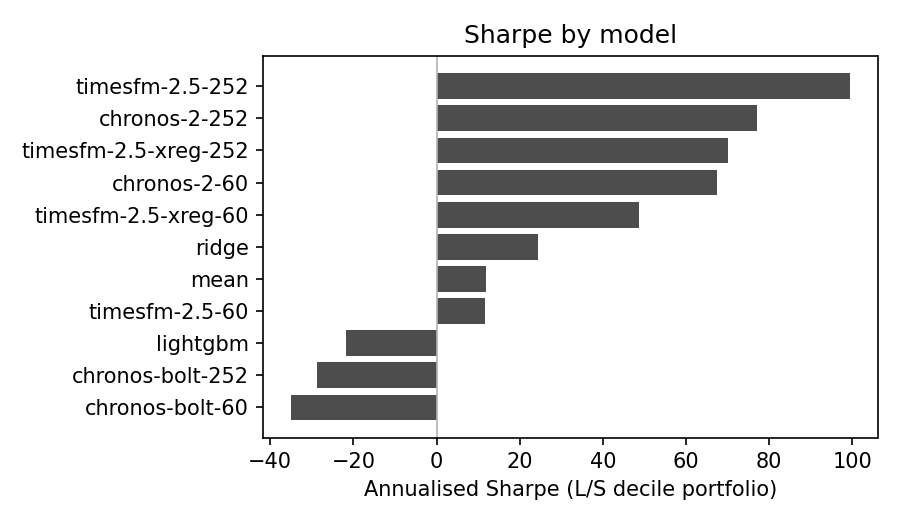

**equity_curves.png**

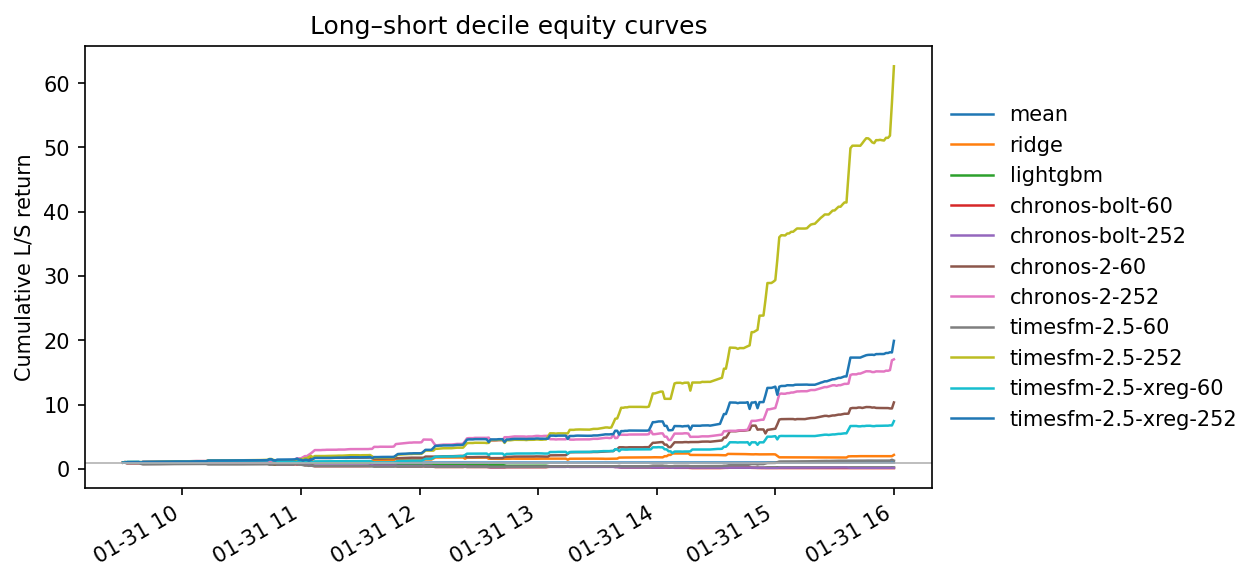

**latency_p95.png**

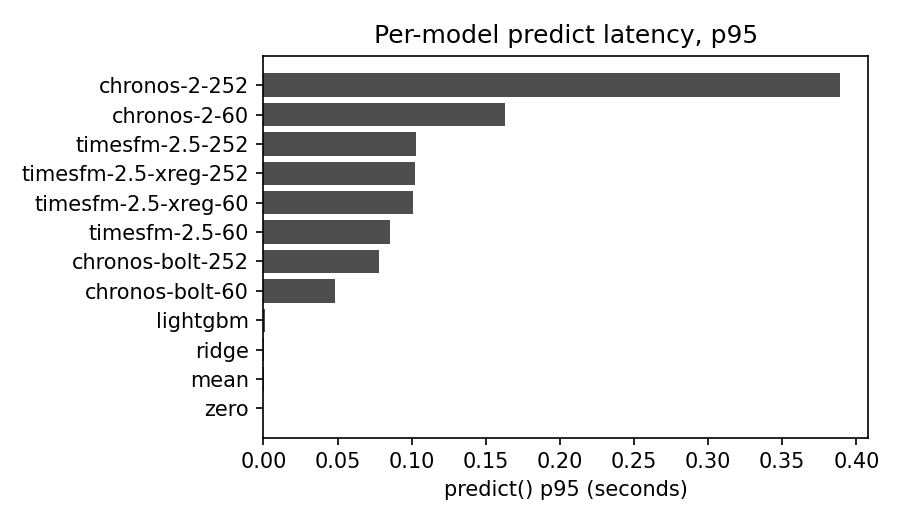

**latency_throughput.png**

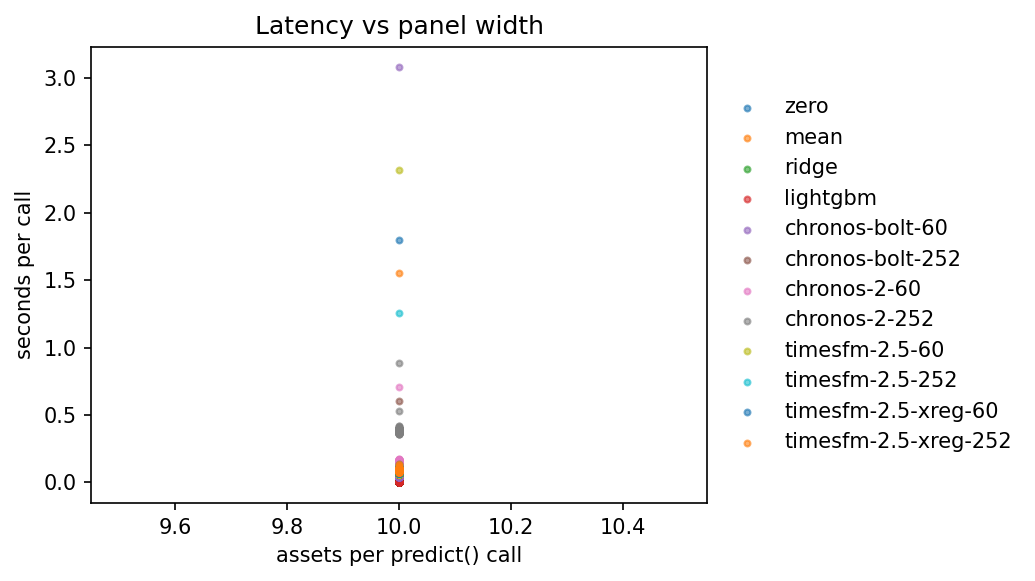

In [6]:
display_benchmark("intraday_1m_wrds")

## Failure Cases and Limitations

The final writeup preserves model underperformance rather than filtering it away. Current limitations include WRDS credential requirements for canonical reproduction, model weights downloaded at runtime, and optional MOIRAI support being blocked from the default run by Torch/Uni2TS version constraints. If a result artifact is stale relative to its config, the benchmark section above calls that out explicitly.

## AI Usage

AI assistance was used for implementation, debugging, documentation, and report drafting. All generated code and claims were reviewed against local tests, source files, and produced artifacts. See `AI_USAGE.md` for details.